In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

In [5]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [7]:
df.shape

(374, 13)

In [8]:
df['Gender'].value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

In [9]:
df['Occupation'].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [10]:
df['Gender'] = df['Gender'].map({"Male":1, "Female":0})

In [11]:
df["BMI Category"].value_counts()

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

In [12]:
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

In [13]:
df["BMI Category"].value_counts()

BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

In [14]:
df['BMI Category'] = df['BMI Category'].map({"Normal":1,"Overweight":2,"Obese":3})

In [15]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,1,27,Software Engineer,6.1,6,42,6,2,126/83,77,4200,NaN
1,2,1,28,Doctor,6.2,6,60,8,1,125/80,75,10000,NaN
2,3,1,28,Doctor,6.2,6,60,8,1,125/80,75,10000,NaN
3,4,1,28,Sales Representative,5.9,4,30,8,3,140/90,85,3000,Sleep Apnea
4,5,1,28,Sales Representative,5.9,4,30,8,3,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,0,59,Nurse,8.1,9,75,3,2,140/95,68,7000,Sleep Apnea
370,371,0,59,Nurse,8.0,9,75,3,2,140/95,68,7000,Sleep Apnea
371,372,0,59,Nurse,8.1,9,75,3,2,140/95,68,7000,Sleep Apnea
372,373,0,59,Nurse,8.1,9,75,3,2,140/95,68,7000,Sleep Apnea


In [23]:
df['Occupation'].value_counts()

Occupation
Nurse          73
Doctor         71
Engineer       63
Lawyer         47
Teacher        40
Accountant     37
Salesperson    32
Other          11
Name: count, dtype: int64

In [22]:
df['Occupation'] = df['Occupation'].replace(
    ['Scientist','Software Engineer','Sales Representative','Manager'],
    'Other'
)

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Occupation'] = le.fit_transform(df['Occupation'])

In [27]:
df['Occupation'].value_counts()

Occupation
4    73
1    71
2    63
3    47
7    40
0    37
6    32
5    11
Name: count, dtype: int64

In [26]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,1,27,5,6.1,6,42,6,2,126/83,77,4200,NaN
1,2,1,28,1,6.2,6,60,8,1,125/80,75,10000,NaN
2,3,1,28,1,6.2,6,60,8,1,125/80,75,10000,NaN
3,4,1,28,5,5.9,4,30,8,3,140/90,85,3000,Sleep Apnea
4,5,1,28,5,5.9,4,30,8,3,140/90,85,3000,Sleep Apnea


In [31]:
df['Sleep Disorder'].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [32]:
df['Sleep Disorder']=df['Sleep Disorder'].map({"Sleep Apnea":0, "Insomnia" :1})

In [34]:
df['Sleep Disorder'].isnull().sum()

np.int64(219)

In [35]:
df['Sleep Disorder'].fillna(df['Sleep Disorder'].mode()[0], inplace=True)

C:\Users\sajal\AppData\Local\Temp\ipykernel_10564\899447769.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Disorder'].fillna(df['Sleep Disorder'].mode()[0], inplace=True)


In [44]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

In [45]:
df.drop('Blood Pressure', axis=1, inplace=True)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    int64  
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    int64  
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    int64  
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           374 non-null    float64
 12  Systolic_BP              374 non-null    int64  
 13  Diastolic_BP             374 non-null    int64  
dtypes: float64(2), int64(12)
m

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X = df.drop(['Stress Level'], axis= 1)
y = df['Stress Level']

In [49]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
y_pred = model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9919354838709677


In [54]:
importance = model.feature_importances_
features = X.columns

pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

,Feature,Importance
4,Sleep Duration,0.188719
8,Heart Rate,0.132689
5,Quality of Sleep,0.131899
9,Daily Steps,0.089700
0,Person ID,0.083259
2,Age,0.080649
11,Systolic_BP,0.066083
6,Physical Activity Level,0.062106
12,Diastolic_BP,0.058563
3,Occupation,0.048514


In [55]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[25,  0,  0,  0,  0,  0],
       [ 0, 17,  0,  0,  0,  0],
       [ 0,  0, 21,  0,  0,  0],
       [ 0,  1,  0, 14,  0,  0],
       [ 0,  0,  0,  0, 21,  0],
       [ 0,  0,  0,  0,  0, 25]])

In [56]:
X = df.drop(["Stress Level","Person ID","Sleep Disorder","BMI Category"], axis=1)
y = df["Stress Level"]

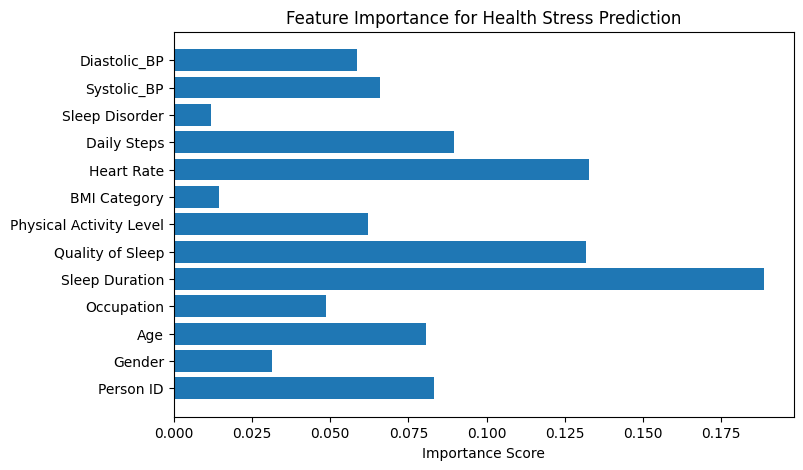

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance for Health Stress Prediction")
plt.xlabel("Importance Score")
plt.show()

In [58]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)

In [65]:
X

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
0,1,27,5,6.1,6,42,77,4200,126,83
1,1,28,1,6.2,6,60,75,10000,125,80
2,1,28,1,6.2,6,60,75,10000,125,80
3,1,28,5,5.9,4,30,85,3000,140,90
4,1,28,5,5.9,4,30,85,3000,140,90
...,...,...,...,...,...,...,...,...,...,...
369,0,59,4,8.1,9,75,68,7000,140,95
370,0,59,4,8.0,9,75,68,7000,140,95
371,0,59,4,8.1,9,75,68,7000,140,95
372,0,59,4,8.1,9,75,68,7000,140,95


In [59]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
y_pred = model.predict(X_test)
y_pred

array([3, 8, 8, 3, 8, 7, 8, 4, 3, 5, 7, 6, 5, 8, 5, 8, 6, 7, 3, 4, 6, 5,
       8, 4, 4, 5, 7, 7, 7, 3, 6, 4, 6, 3, 8, 4, 8, 6, 5, 5, 7, 8, 7, 7,
       5, 4, 4, 6, 8, 6, 3, 5, 8, 5, 6, 3, 5, 8, 3, 8, 5, 7, 8, 6, 4, 8,
       7, 3, 5, 5, 4, 7, 3, 8, 3, 7, 8, 5, 3, 7, 4, 8, 6, 5, 4, 3, 3, 8,
       5, 4, 3, 8, 5, 3, 7, 7, 5, 8, 7, 6, 5, 3, 3, 4, 4, 3, 4, 3, 3, 3,
       8, 5, 7, 6, 3, 8, 6, 7, 7, 4, 8, 4, 3, 7])

In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9919354838709677


In [69]:
import pandas as pd

test_input = pd.DataFrame({
    "Gender":[0],          # encoded value
    "Age":[20],
    "Occupation":[5],      # encoded value
    "Sleep Duration":[8],
    "Quality of Sleep":[10],
    "Physical Activity Level":[20],
    "Heart Rate":[85],
    "Daily Steps":[3000],
    "Systolic_BP":[120],
    "Diastolic_BP":[90],
})

prediction = model.predict(test_input)

print("Predicted Stress Level:", prediction[0])

Predicted Stress Level: 3


In [70]:
!pip install joblib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
import joblib

In [72]:
joblib.dump(model,"health_stress_model.pkl")

['health_stress_model.pkl']